In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datasets.dataset_utils_empty import AtomSelection
protein_name = "bba"
atom_selection = AtomSelection.A_CARBON


/home/sanjeevr/miniforge3/envs/alphaflow/lib/python3.9/site-packages/mdtraj/__init__.py:55: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.2)
  from ._lprmsd import lprmsd


In [3]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from utils import TorchMD_CGProteinPriorForces

def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")

device = torch.device("cuda:8")

gen_mode = "langevin" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = None # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
all_atom_append = "_all_atom" if atom_selection == AtomSelection.PROTEIN else ""
eval_folder = f"./saved_models/{protein_name}{all_atom_append}/main_eval_output_{gen_mode}{append_exp_name_str}"

# min-flux endpoints (not using for now)
cluster_endpoints_path = Path(
        os.path.join(
            "evaluate",
            "saved_references",
            f"saved_cluster_endpoints_{protein_name.upper()}{all_atom_append}.npy",
        )
    )

pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-{atom_selection.value}.pdb"

# Load samples from the ground truth simulations to serve as training data
gt_traj_path = os.path.join(
        "/data/sanjeevr/Reference_MD_Sims",
        Molecules[protein_name.upper()].value,
        f"gt_traj{all_atom_append}.pt",
    )
if os.path.exists(gt_traj_path):
    gt_traj = 10*torch.load(gt_traj_path)
else:
    print("Loading reference simulations")
    dataset = DEShawDataset(
        data_root="/data/sanjeevr/Reference_MD_Sims",
        molecule=Molecules[protein_name.upper()],
        simulation_id=0,
        atom_selection=atom_selection,
        return_bond_graph=False,
        transform=to_angstrom,
        align=False,
    )

    gt_traj = 10 * torch.tensor(dataset.traj.xyz)  # convert to angstroms
gt_traj -= gt_traj.mean(1, keepdims=True)  # center

# gt_traj = gt_traj[::100]

n_atoms = gt_traj.shape[1]

# Load topology from pdb file
topology = md.load(pdb_file).topology

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}{all_atom_append}.npy",
    )
)
cluster_coords = np.load(cluster_centers_path)

# Get TICA
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=eval_folder,
    data_folder="datasets",
    atom_selection=atom_selection,
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)
# assign cluster centers to the reference samples
cluster_assignments, transformed_samples = discretize_trajectory(
    gt_traj, tic_evaluator, cluster_coords
)

cluster_assignments = torch.tensor(cluster_assignments)

# protein_prior = TorchMD_CGProteinPriorForces(
#                 yaml_file="./dynamics/cg_prior_force_field.yaml",
#                 topology_file=f"./datasets/folded_pdbs/cg_{protein_name}.psf",
#                 device = device,
#             )

/tmp/ipykernel_95375/3048953851.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gt_traj = 10*torch.load(gt_traj_path)


In [37]:
# doobs_samples = torch.tensor(np.load("/home/sanjeevr/om-diffusion/Variational-Doob/out/trp_cg_diagonal/deterministic_paths.npy"))
# doobs_samples = 10*doobs_samples.reshape(-1, n_atoms, 3)

# cluster_assignments_doobs, transformed_samples_doob = discretize_trajectory(
#     doobs_samples, tic_evaluator, cluster_coords
# )

# cg_forces = torch.vmap(protein_prior)(gt_traj[::100].to(device))[1]
# cg_forces.shape

torch.Size([10440, 20, 3])

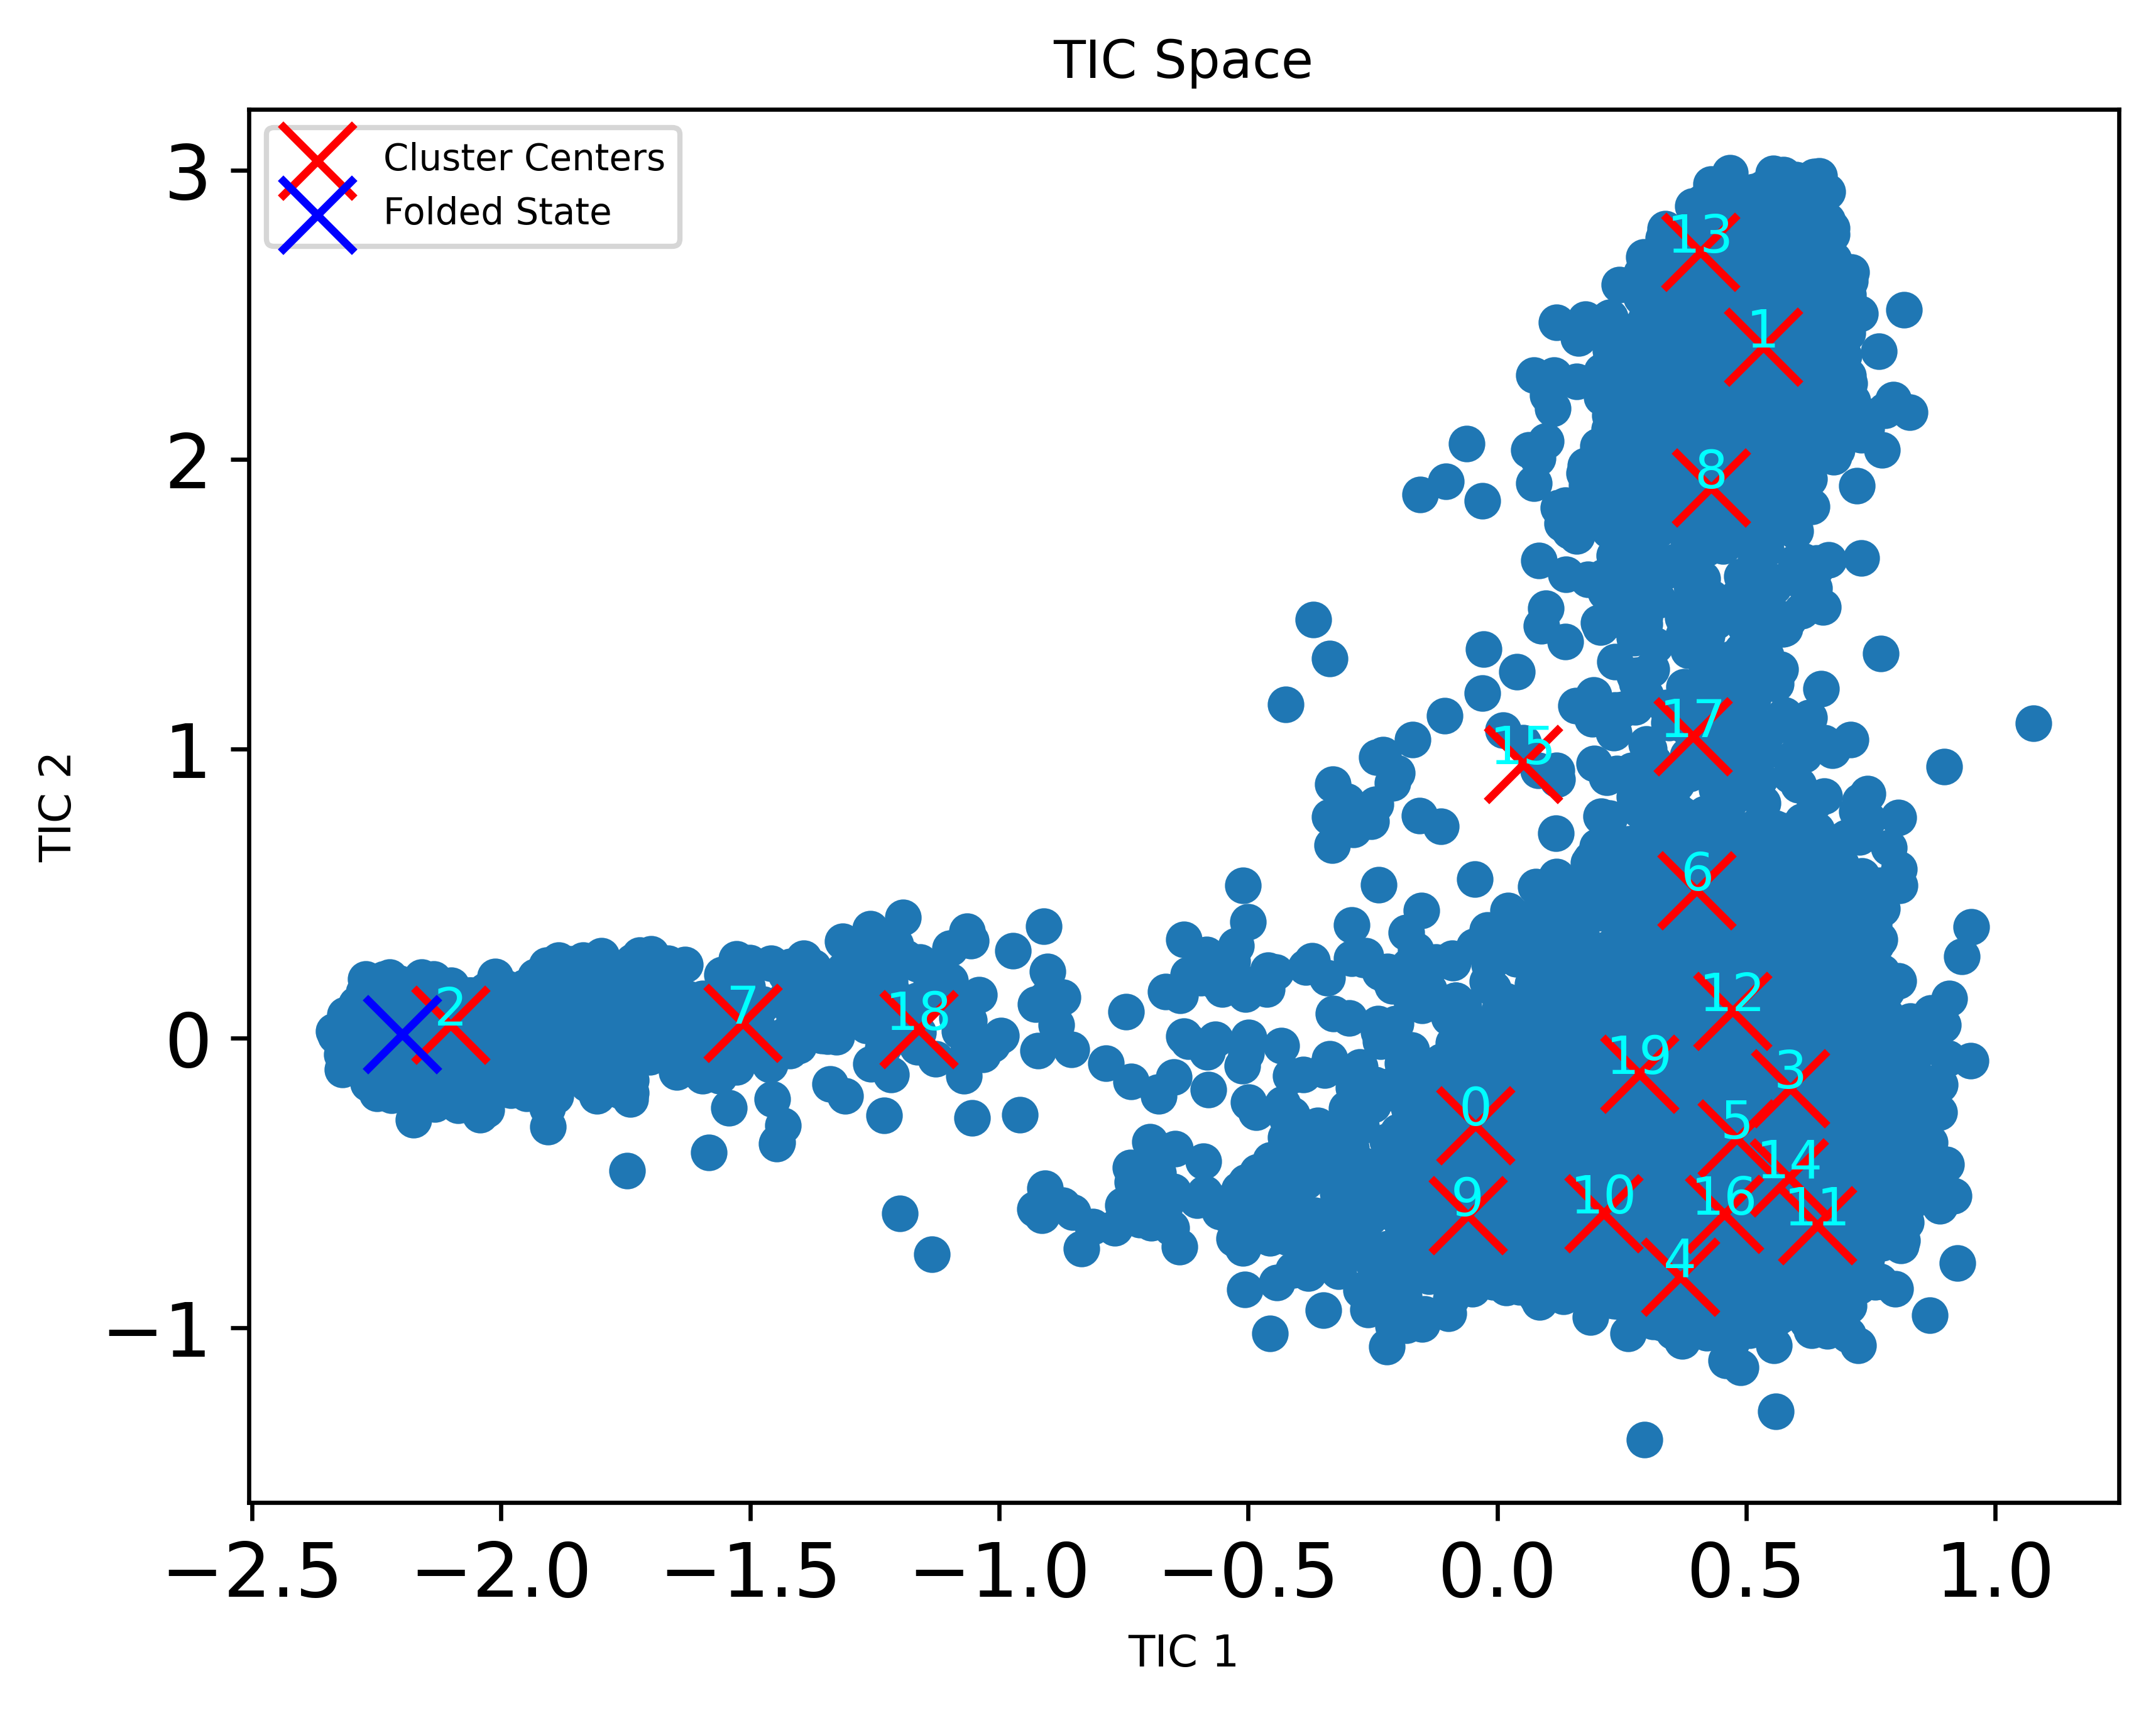

In [5]:
# Plot the TICA space with black points and red 'x' markers for cluster centers

plt.figure()
plt.scatter(transformed_samples[::100, 0], transformed_samples[::100, 1])
# plt.scatter(transformed_samples_doob[:, 0], transformed_samples_doob[:, 1], c='green', s=10)
plt.scatter(cluster_coords[:, 0], cluster_coords[:, 1], c='red', s=200, marker='x', label='Cluster Centers')

plt.scatter(tic_evaluator.folded_transform[0], tic_evaluator.folded_transform[1], c='blue', s=200, marker='x', label='Folded State')

# Add a text label above each cluster center with its index
for i, (x, y) in enumerate(cluster_coords):
    plt.text(x, y, str(i), color='cyan', fontsize=10, ha='center')

# Set plot title and axis labels
plt.title("TIC Space")
plt.xlabel("TIC 1")
plt.ylabel("TIC 2")

# Show the plot
plt.legend()
plt.show()

In [4]:
# Digitize samples into bins
bins_x = np.digitize(transformed_samples[:, 0], tic_evaluator.bin_edges_x) - 1
bins_y = np.digitize(transformed_samples[:, 1], tic_evaluator.bin_edges_y) - 1

# Clip to ensure all indices are within bounds
bins_x = np.clip(bins_x, 0, tic_evaluator.bins - 1)
bins_y = np.clip(bins_y, 0, tic_evaluator.bins - 1)

reweighting_factors = torch.tensor(tic_evaluator.gt_prob[bins_x, bins_y]) + 1e-5

In [5]:
def get_gt_committor_probs(tic_samples, start_cluster, end_cluster, clusters, tic):
    n_samples = tic_samples.shape[0]
    
    
    # Digitize samples into bins
    bins_x = np.digitize(tic_samples[:, 0], tic.bin_edges_x) - 1
    bins_y = np.digitize(tic_samples[:, 1], tic.bin_edges_y) - 1
    
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, tic.bins - 1)
    bins_y = np.clip(bins_y, 0, tic.bins - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * tic.bins + bins_y

    if os.path.exists(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy"):
        committor_probs = np.load(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy")
        return committor_probs[bin_idx]
    
    # Initialize committor probabilities tensor
    committor_probs = torch.zeros(tic.bins ** 2)
    bin_counts = torch.zeros(tic.bins ** 2)
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    for i in tqdm(range(n_samples)):
        bin_counts[bin_idx[i]] += 1
        if last_transition_idx is not None and i <= last_transition_idx:
            # If we already determined the committor for the intermediate steps, assign and skip
            committor_probs[bin_idx[i]] += last_committor
        else:
            if is_start[i]:
                committor_probs[bin_idx[i]] += 0
                last_committor = 0
                last_transition_idx = i
            elif is_end[i]:
                committor_probs[bin_idx[i]] += 1
                last_committor = 1
                last_transition_idx = i
            else:
                # Search forward in the trajectory to find the next transition
                subsequent_clusters = clusters[i:]
                first_start = np.argmax(subsequent_clusters == start_cluster)
                first_end = np.argmax(subsequent_clusters == end_cluster)

                if (first_end == 0 or first_start > 0 and first_start < first_end):
                    last_committor = 0
                    last_transition_idx = i + first_start
                elif (first_end > 0 and (first_start == 0 or first_end < first_start)):
                    last_committor = 1
                    last_transition_idx = i + first_end
                else:
                    raise RuntimeError(f"No transition found for sample {i}")
                
                # Assign committor for current step
                committor_probs[bin_idx[i]] += last_committor
    
    # Normalize committor probabilities by bin counts
    committor_probs = committor_probs / torch.clamp(bin_counts, min=1)
    
    # Save bin-wise committor probabilities
    np.save(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy", committor_probs)
    
    return committor_probs[bin_idx]


start, end = CLUSTER_ENDPOINTS[protein_name]
probs = get_gt_committor_probs(transformed_samples, start, end, cluster_assignments, tic_evaluator)
probs = torch.tensor(probs)


In [6]:
frac_start = (cluster_assignments == start).float().mean()
frac_end = (cluster_assignments == end).float().mean()


def get_gt_first_passage_time(tic_samples, start_cluster, end_cluster, clusters):
    n_samples = tic_samples.shape[0]
    
    first_passage_times = []
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    i=0
    count=0
    independent_transition_events = 0
    while i < n_samples:
        if is_start[i]:  # Found a start state
            subsequent_clusters = clusters[i:]  

            # Check if a transition exists
            if (subsequent_clusters == end_cluster).any():   
                independent_transition_events += 1           
                first_end = np.argmax(subsequent_clusters == end_cluster)  # Find first passage
                # Create an array of indices in the range [i, i + first_end]
                valid_start_indices = np.arange(i, i + first_end + 1)[is_start[i:i + first_end + 1]]
                # Compute passage times using vectorized operations
                passage_times = 0.2 * (i + first_end - valid_start_indices)
                # Efficiently extend the list in one operation
                first_passage_times.extend(passage_times)
                i += first_end  # Skip ahead to the next relevant point
            else:
                break  # No valid transition found, exit
        else:
            i += 1  # Skip non-start states
        count +=1
            
    first_passage_time = np.mean(np.array(first_passage_times))
    first_passage_time
                
    # Save rates
    # np.save(f"./evaluate/saved_references/{protein_name}_gt_rate_{start_cluster}_{end_cluster}.npy", rate)
    
    return first_passage_time, independent_transition_events

# Direct Counting 
start, end = CLUSTER_ENDPOINTS[protein_name]
mfpt_forward, independent_transition_events = get_gt_first_passage_time(transformed_samples, start, end, cluster_assignments)
mfpt_backward, _ = get_gt_first_passage_time(transformed_samples, end, start, cluster_assignments)
# mfpt_backward = 0
rate_forward = 1 / mfpt_forward
rate_backward = 1 / mfpt_backward
rate = 1 / (mfpt_forward + mfpt_backward)

print(f"Rate from direct counting: {rate} ns-1, with {independent_transition_events} independent transition events")

import numpy as np
import torch
from deeptime.markov.tools.analysis import mfpt
prob_mat = np.load(f"./evaluate/saved_references/saved_transition_matrix_{(protein_name).upper()}.npy")
fpt = mfpt(prob_mat, end, start, tau=0.2) + mfpt(prob_mat, start, end, tau=0.2)
rate = 1 / fpt
print(f"Rate from MSM analysis: {rate} ns^-1")




Rate from direct counting: 3.917273008757171e-05 ns-1, with 11 independent transition events
Rate from MSM analysis: 0.00266882041157453 ns^-1


In [7]:
frac_start = (cluster_assignments == start).float().mean()
frac_end = (cluster_assignments == end).float().mean()

# TODO: compute the rate from the number of times the transition is observed (defined as when the committor crosses 0.5)

def get_gt_rate(committor_probs, frac_start, frac_end):
    
    n_samples = committor_probs.shape[0]
    
    crossing_events_forward = 0
    crossing_events_reverse = 0
    for i in tqdm(range(n_samples-1)):
        if committor_probs[i] < 0.45 and committor_probs[i+1] > 0.55:
            crossing_events_forward += 1
        elif committor_probs[i] > 0.55 and committor_probs[i+1] < 0.45:
            crossing_events_reverse += 1


    
    total_time_ns = 0.2 * len(committor_probs)
    total_time_ns_start = total_time_ns * frac_start
    total_time_ns_end = total_time_ns * frac_end
    rate_start = crossing_events_forward / total_time_ns_start
    rate_end = crossing_events_reverse / total_time_ns_end
    print(f"Forward crossing events: {crossing_events_forward}, Reverse crossing events: {crossing_events_reverse}")
                
    # Save rates
    # np.save(f"./evaluate/saved_references/{protein_name}_gt_rate_{start_cluster}_{end_cluster}.npy", rate)
    
    return rate_start, rate_end

# Direct Counting 
start, end = CLUSTER_ENDPOINTS[protein_name]
rate_forward, rate_backward = get_gt_rate(probs, frac_start, frac_end)
print(f"Rates from direct counting: {rate_forward} ns-1, {rate_backward} ns-1")

import numpy as np
import torch
from deeptime.markov.tools.analysis import mfpt
prob_mat = np.load(f"./evaluate/saved_references/saved_transition_matrix_{(protein_name).upper()}.npy")
fpt = mfpt(prob_mat, end, start, tau=0.2) + mfpt(prob_mat, start, end, tau=0.2)
rate = 1 / fpt
print(f"Rate from MSM analysis: {rate} ns^-1")




100%|██████████| 1114544/1114544 [00:15<00:00, 70162.50it/s]

Forward crossing events: 4635, Reverse crossing events: 4621
Rates from direct counting: 1.1596777439117432 ns-1, 0.7654464244842529 ns-1
Rate from MSM analysis: 0.00266882041157453 ns^-1


In [8]:
# Analyze when the trajectory crosses from the start to the end state
def extract_transition_windows(clusters: torch.Tensor, start_cluster, end_cluster, max_windows: int = 10):
    clusters = clusters.flatten()
    n = len(clusters)
    windows = []

    i = 0
    while i < n and (max_windows is None or len(windows) < max_windows):
        # Find the next zero
        while i < n and clusters[i] != start_cluster:
            i += 1
        if i == n:
            break
        start = i

        # Now traverse until we hit a value >= 1
        while i < n and clusters[i] != end_cluster:
            i += 1

        if i < n:
            end = i
            windows.append((start, end))
            i += 1  # Continue search from next element
        else:
            break  # No complete rising window found

    
    return torch.tensor(windows)

transition_windows = extract_transition_windows(cluster_assignments, start, end, max_windows=10)

In [45]:
transition_windows

tensor([[ 32751, 102664],
        [117468, 137950],
        [199123, 356411],
        [361112, 384778],
        [404400, 438694],
        [443590, 446092],
        [485506, 588689],
        [594698, 821346],
        [866900, 882271],
        [941309, 995487]])

> /tmp/ipykernel_95375/3305620896.py(50)<module>()
     48 for i, window in enumerate([tica_transition_windows[0]]):
     49     import pdb; pdb.set_trace()
---> 50     window = window[::100]
     51     points = window.reshape(-1, 1, 2)
     52     segments = np.concatenate([points[:-1], points[1:]], axis=1)

(2802, 2)


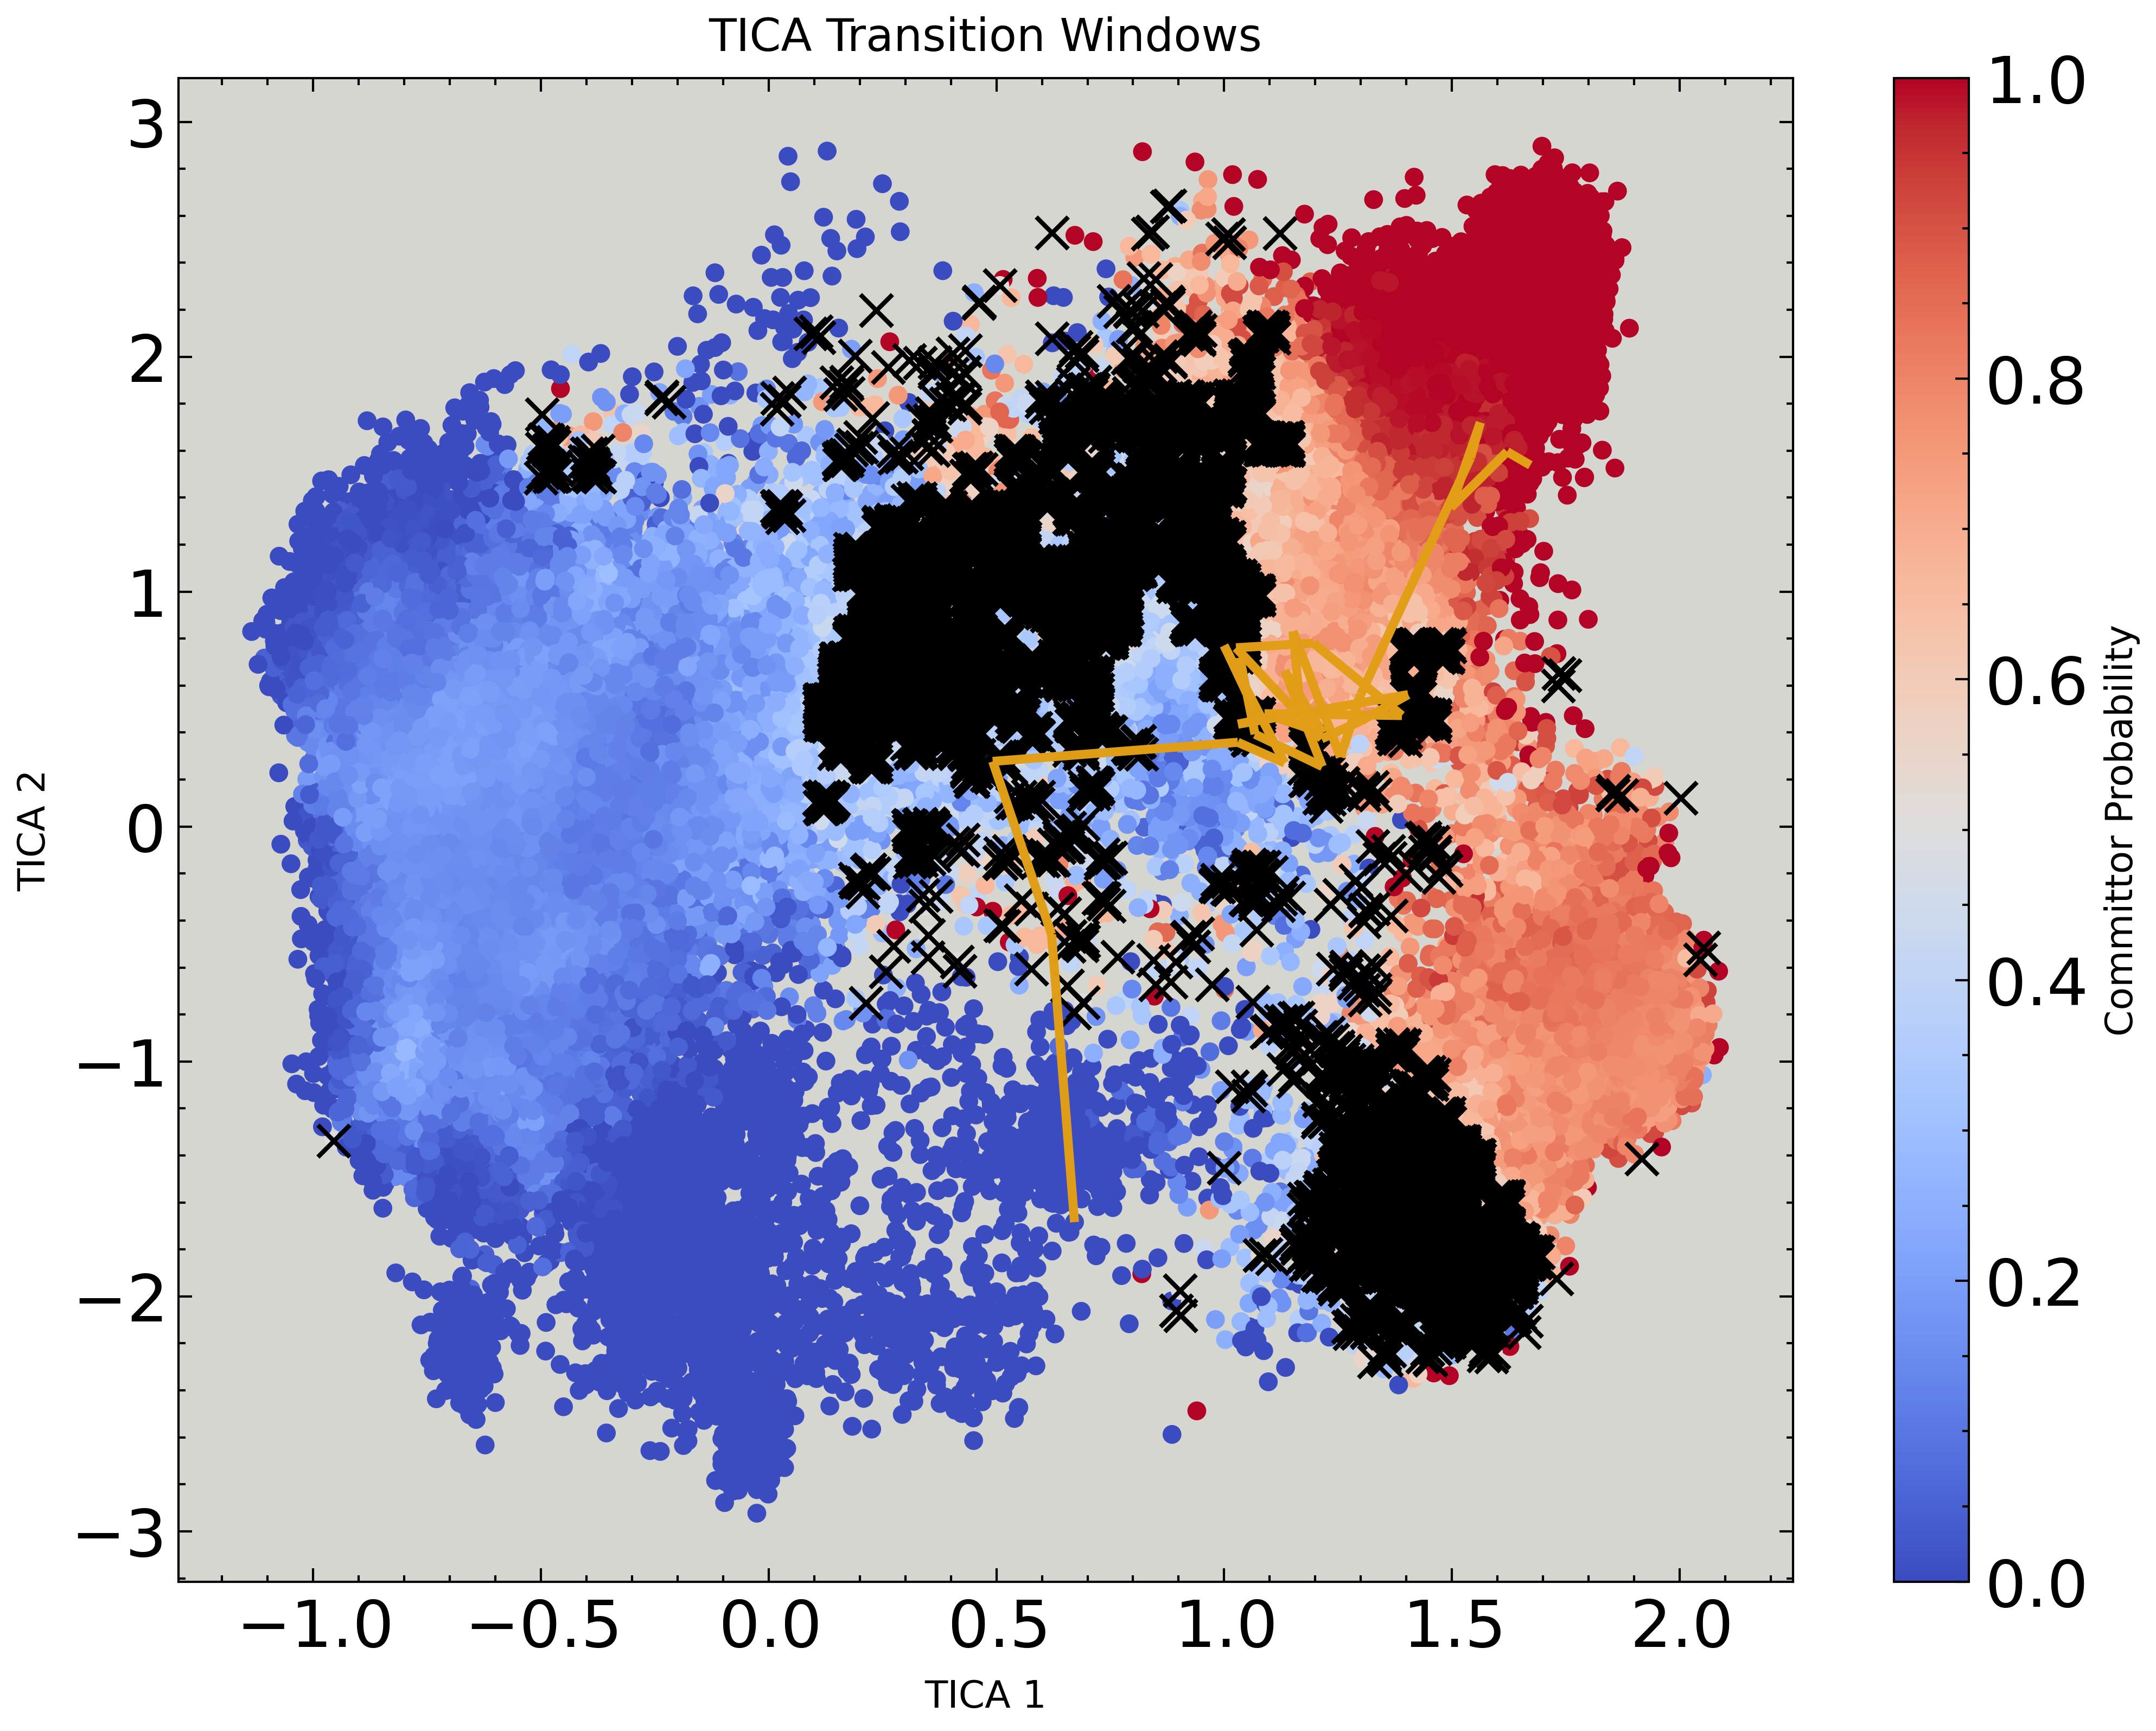

In [49]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
import numpy as np
import scienceplots
plt.style.use(['science','no-latex'])
import matplotlib.pylab as pylab
params = {'figure.dpi': 600,
            'axes.labelsize': 'small',
          'legend.fontsize': 'x-small',
         'axes.titlesize':'medium',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'font.family': 'DejaVu Sans'}
from matplotlib import rc
pylab.rcParams.update(params)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot main scatter
scatter = ax.scatter(transformed_samples[::100, 0], transformed_samples[::100, 1],
                     c=probs[::100], cmap='coolwarm', s=10)
ax = plt.gca()  # Get the current axis
ax.set_facecolor('#d5d6d0')  # Set the background color to gray
fig.colorbar(scatter, ax=ax, label='Committor Probability')

# Transition state ensemble
mask = (probs[::2] > 0.45) & (probs[::2] < 0.55)
transition_state_samples = transformed_samples[::2][mask]

# Plot transition state samples
ax.scatter(
    transition_state_samples[:, 0], 
    transition_state_samples[:, 1], 
    marker='x',
    c='black',
    s=50, 
    alpha=1.0,
    label='Transition State Ensemble'
)

# Sort and plot transition windows
tica_transition_windows = [transformed_samples[start:end+300] for start, end in transition_windows]
tica_transition_windows = sorted(tica_transition_windows, key=lambda x: len(x))
colors = ["#e29e16", "#4c199e", "#ecf535","#199e26", "#EEEFF7"]


for i, window in enumerate([tica_transition_windows[0]]):
    window = window[::100]
    points = window.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    alphas = np.linspace(0.99, 1.0, len(segments))
    rgb = mcolors.to_rgb(colors[i % len(colors)])
    rgba_colors = [(rgb[0], rgb[1], rgb[2], alpha) for alpha in alphas]
    lc = LineCollection(segments, colors=rgba_colors, linewidths=2)
    ax.add_collection(lc)

ax.set_xlabel('TICA 1')
ax.set_ylabel('TICA 2')
ax.set_title('TICA Transition Windows')
# ax.legend()  # Uncomment if legend is needed
fig.savefig(f"{protein_name}_transition_windows.png")
plt.show()


In [20]:
import numpy as np
end
# prob_mat = np.load("/home/sanjeevr/om-diffusion/two-for-one-diffusion/evaluate/saved_references/saved_transition_matrix_TRP_CAGE.npy")
# prob_mat = torch.tensor(prob_mat)
# # remove end row from prob_mat
# mask = torch.arange(prob_mat.size(0)) != end  # Boolean mask for all indices except i
# reduced_prob_mat = prob_mat[mask][:, mask]

# A = torch.eye(reduced_prob_mat.shape[0]) - reduced_prob_mat
# b = 0.2 * torch.ones((reduced_prob_mat.shape[0],))
# fpts = torch.linalg.solve(A, b)


13

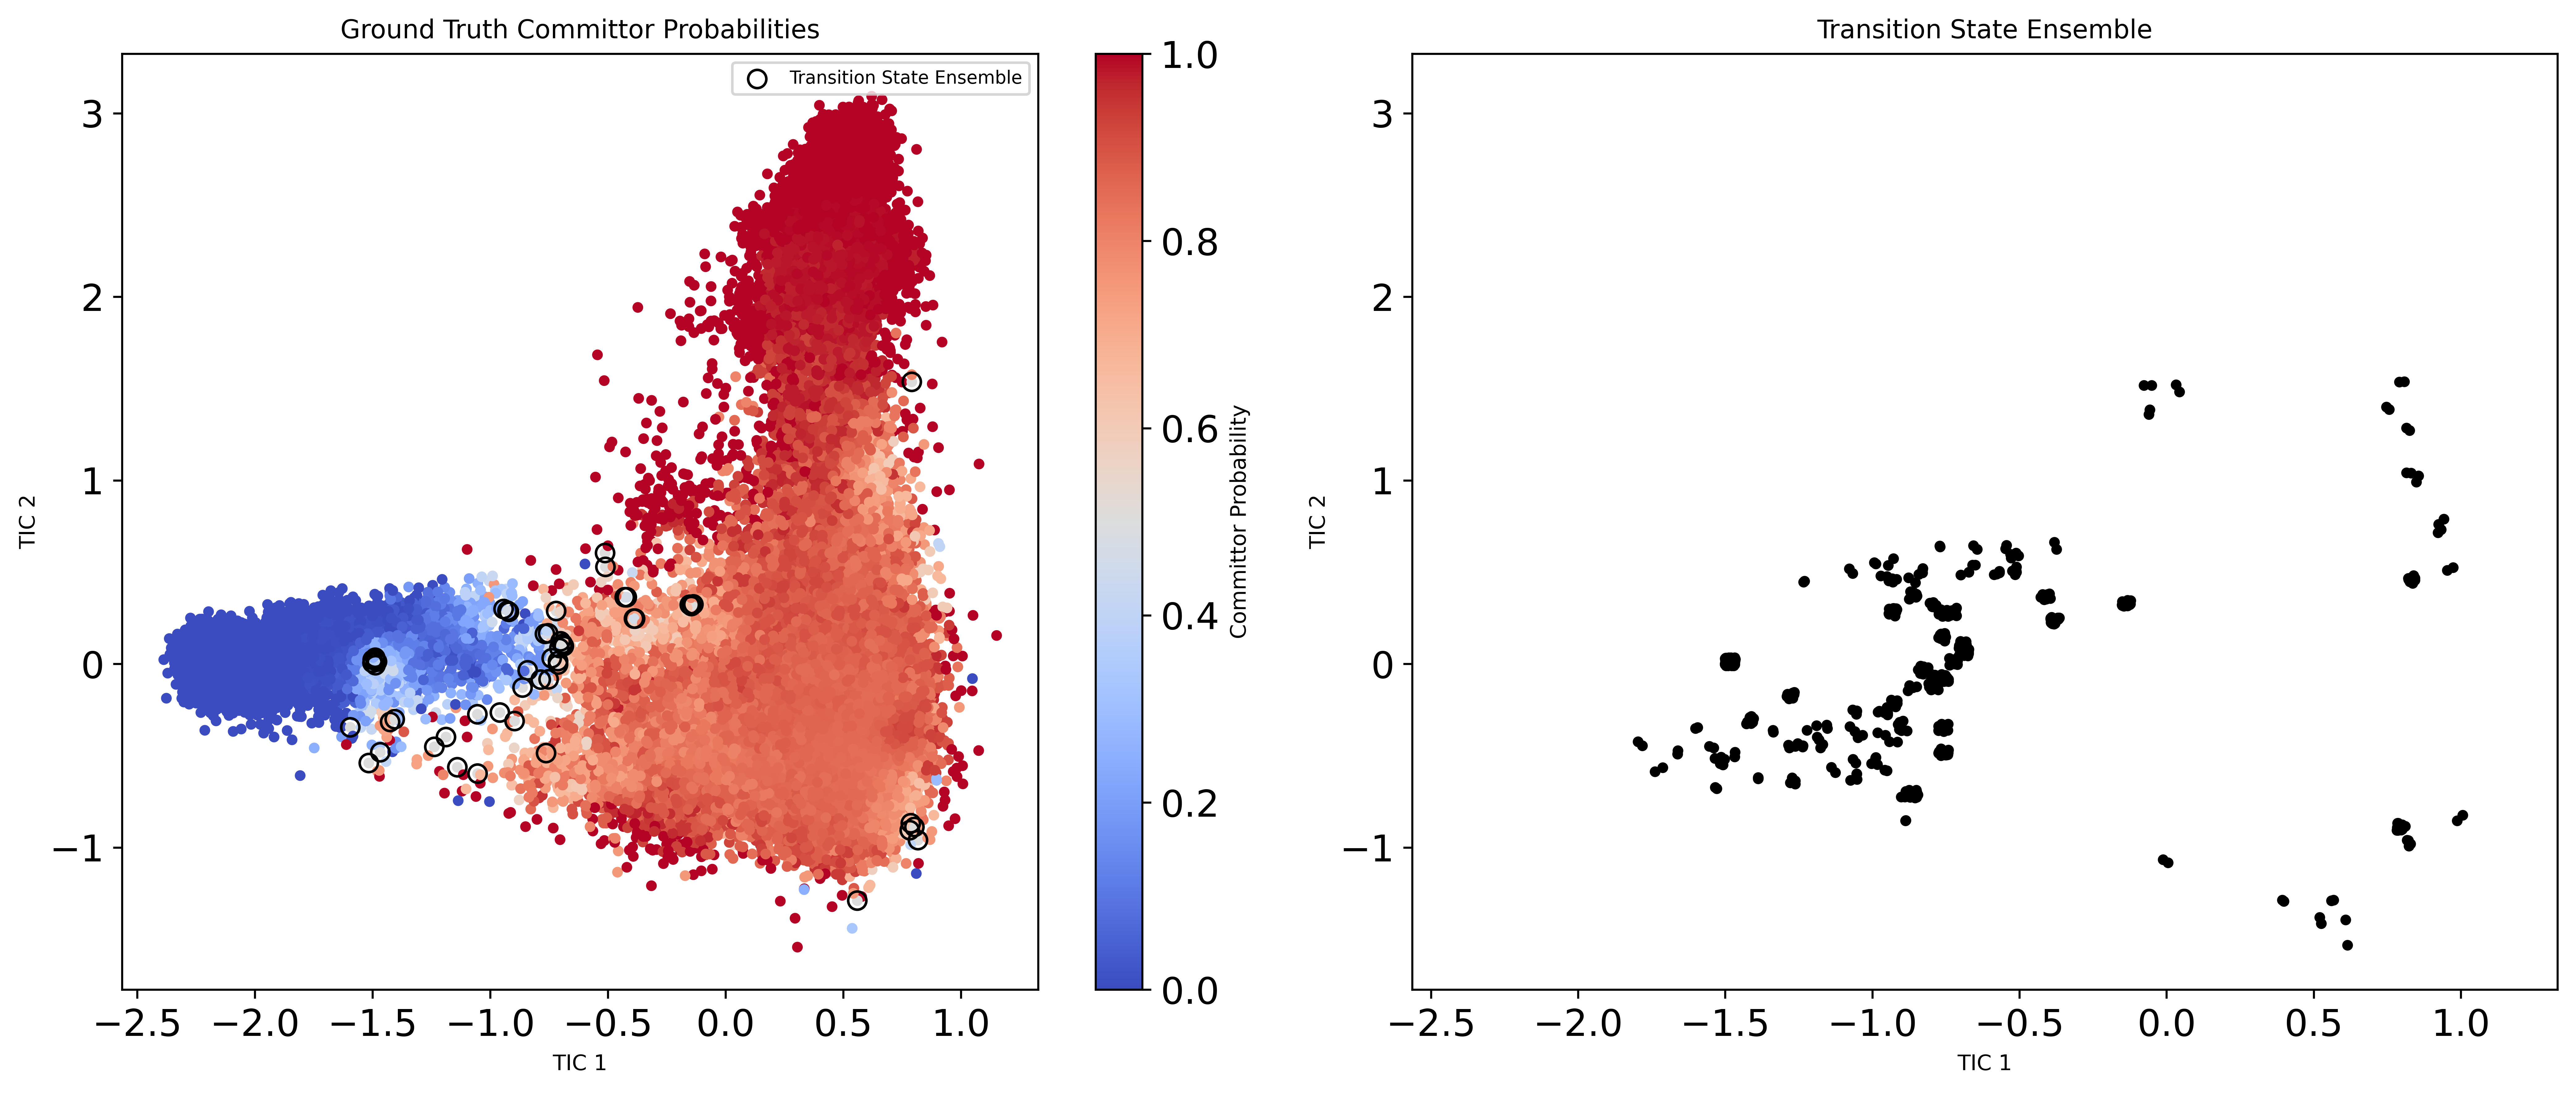

In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# First plot: Ground Truth Committor Probabilities
scatter1 = axs[0].scatter(transformed_samples[::10, 0], transformed_samples[::10, 1], c=probs[::10], cmap='coolwarm', s=10)
axs[0].set_title("Ground Truth Committor Probabilities")
axs[0].set_xlabel("TIC 1")
axs[0].set_ylabel("TIC 2")
# axs[0].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
# axs[0].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
plt.colorbar(scatter1, ax=axs[0], label='Committor Probability')

# Get the axis limits from the first plot
x_limits = axs[0].get_xlim()
y_limits = axs[0].get_ylim()

# Second plot: Transition State Ensemble (committor probability close to 0.5)
subsampled_mask = (probs[::10] > 0.45) & (probs[::10] < 0.55)
# Save TICA coordinates for the transition state ensemble
sub_transition_state_samples = transformed_samples[::10][subsampled_mask]

# Encircle transition state samples
axs[0].scatter(
    sub_transition_state_samples[:, 0], 
    sub_transition_state_samples[:, 1], 
    facecolors='none', 
    edgecolors='black', 
    s=50, 
    linewidths=1.0,
    alpha = 1.0,
    label='Transition State Ensemble'
)


axs[0].legend()

# Second plot: Transition State Ensemble (committor probability close to 0.5)
mask = (probs > 0.45) & (probs < 0.55)
# Save TICA coordinates for the transition state ensemble
transition_state_samples = transformed_samples[mask]


np.save(f"./evaluate/saved_references/{protein_name}_{start}_{end}_transition_ensemble_TICA.npy", transition_state_samples)
scatter2 = axs[1].scatter(transformed_samples[mask, 0], transformed_samples[mask, 1], c='black', s=10)
axs[1].set_title('Transition State Ensemble')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')

# Apply the same axis limits as the first plot
axs[1].set_xlim(x_limits)
axs[1].set_ylim(y_limits)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig(f"./evaluate/saved_references/{protein_name}_{start}_{end}_committor_plots.png")
plt.show()


In [11]:
model = GraphTransformer(num_beads = n_atoms, hidden_nf=64, conservative=True).to(device)

from models import CommittorNN


committor_model = CommittorNN(model)

# Train the model on the sampled molecules
batch_size = 64
n_epochs = 0
max_data_size = 1000000
idxs = np.random.choice(gt_traj.shape[0], max_data_size, replace=False)
optimizer = torch.optim.Adam(committor_model.parameters(), lr=1e-5)
scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 200, \
                                                        total_steps = n_epochs * int(0.8 * max_data_size / batch_size), \
                                                        lr_min=0.0, lr_max=1.0)
train_losses = []
test_losses = []

# split sampled_mol and cluster_assignments into train test sets
gt_traj_keep = gt_traj[idxs]
gt_traj_keep = gt_traj_keep - gt_traj_keep.mean(1, keepdims=True)

cluster_assignments_keep = cluster_assignments[idxs]
gt_probs_keep = probs[idxs]
reweighting_factors_keep = reweighting_factors[idxs]

# TODO: investigate whether the stochasticity in results is due to the random split, the random initialization of the model, or the shuffling of the dataloader
x_train, x_test, cluster_train, cluster_test, probs_train, probs_test = train_test_split(gt_traj_keep, cluster_assignments_keep, gt_probs_keep, test_size=0.2)
trainset = torch.utils.data.TensorDataset(x_train, cluster_train, probs_train)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torch.utils.data.TensorDataset(x_test, cluster_test, probs_test)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

for _ in tqdm(range(n_epochs)):
    committor_model.train()
    for x, cluster, prob in train_dataloader:
        
        optimizer.zero_grad()
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        cluster = cluster.to(device)
        prob = prob.to(device)
        start_mask = cluster == start
        end_mask = cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        grad_loss = grad_prob.square().sum((-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()
        
        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss #5*start_boundary_loss + 5*end_boundary_loss + grad_loss #sl_loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.detach().unsqueeze(-1))
        
    # Test the model on the test set
    committor_model.eval()
    tls = []
    for x, cluster, prob in test_dataloader:
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        cluster = cluster.to(device)
        prob = prob.to(device)
        start_mask = cluster == start
        end_mask = cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        grad_loss = grad_prob.square().sum((-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()

        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss #5*start_boundary_loss + 5*end_boundary_loss + grad_loss
        tls.append(loss.detach().unsqueeze(-1))
    
    test_loss = torch.cat(tls).sum(0) / len(tls)
    test_losses.append(test_loss.unsqueeze(-1))


train_losses = torch.cat(train_losses).cpu().numpy()
test_losses = torch.cat(test_losses).cpu().numpy()

plot_losses(train_losses, test_losses, "Committor training")

# Save the model
torch.save(committor_model, f"./saved_models/{protein_name}/committor-model-{start}_{end}.pt")


0it [00:00, ?it/s]


RuntimeError: torch.cat(): expected a non-empty list of Tensors

100%|██████████| 3125/3125 [00:10<00:00, 303.81it/s]


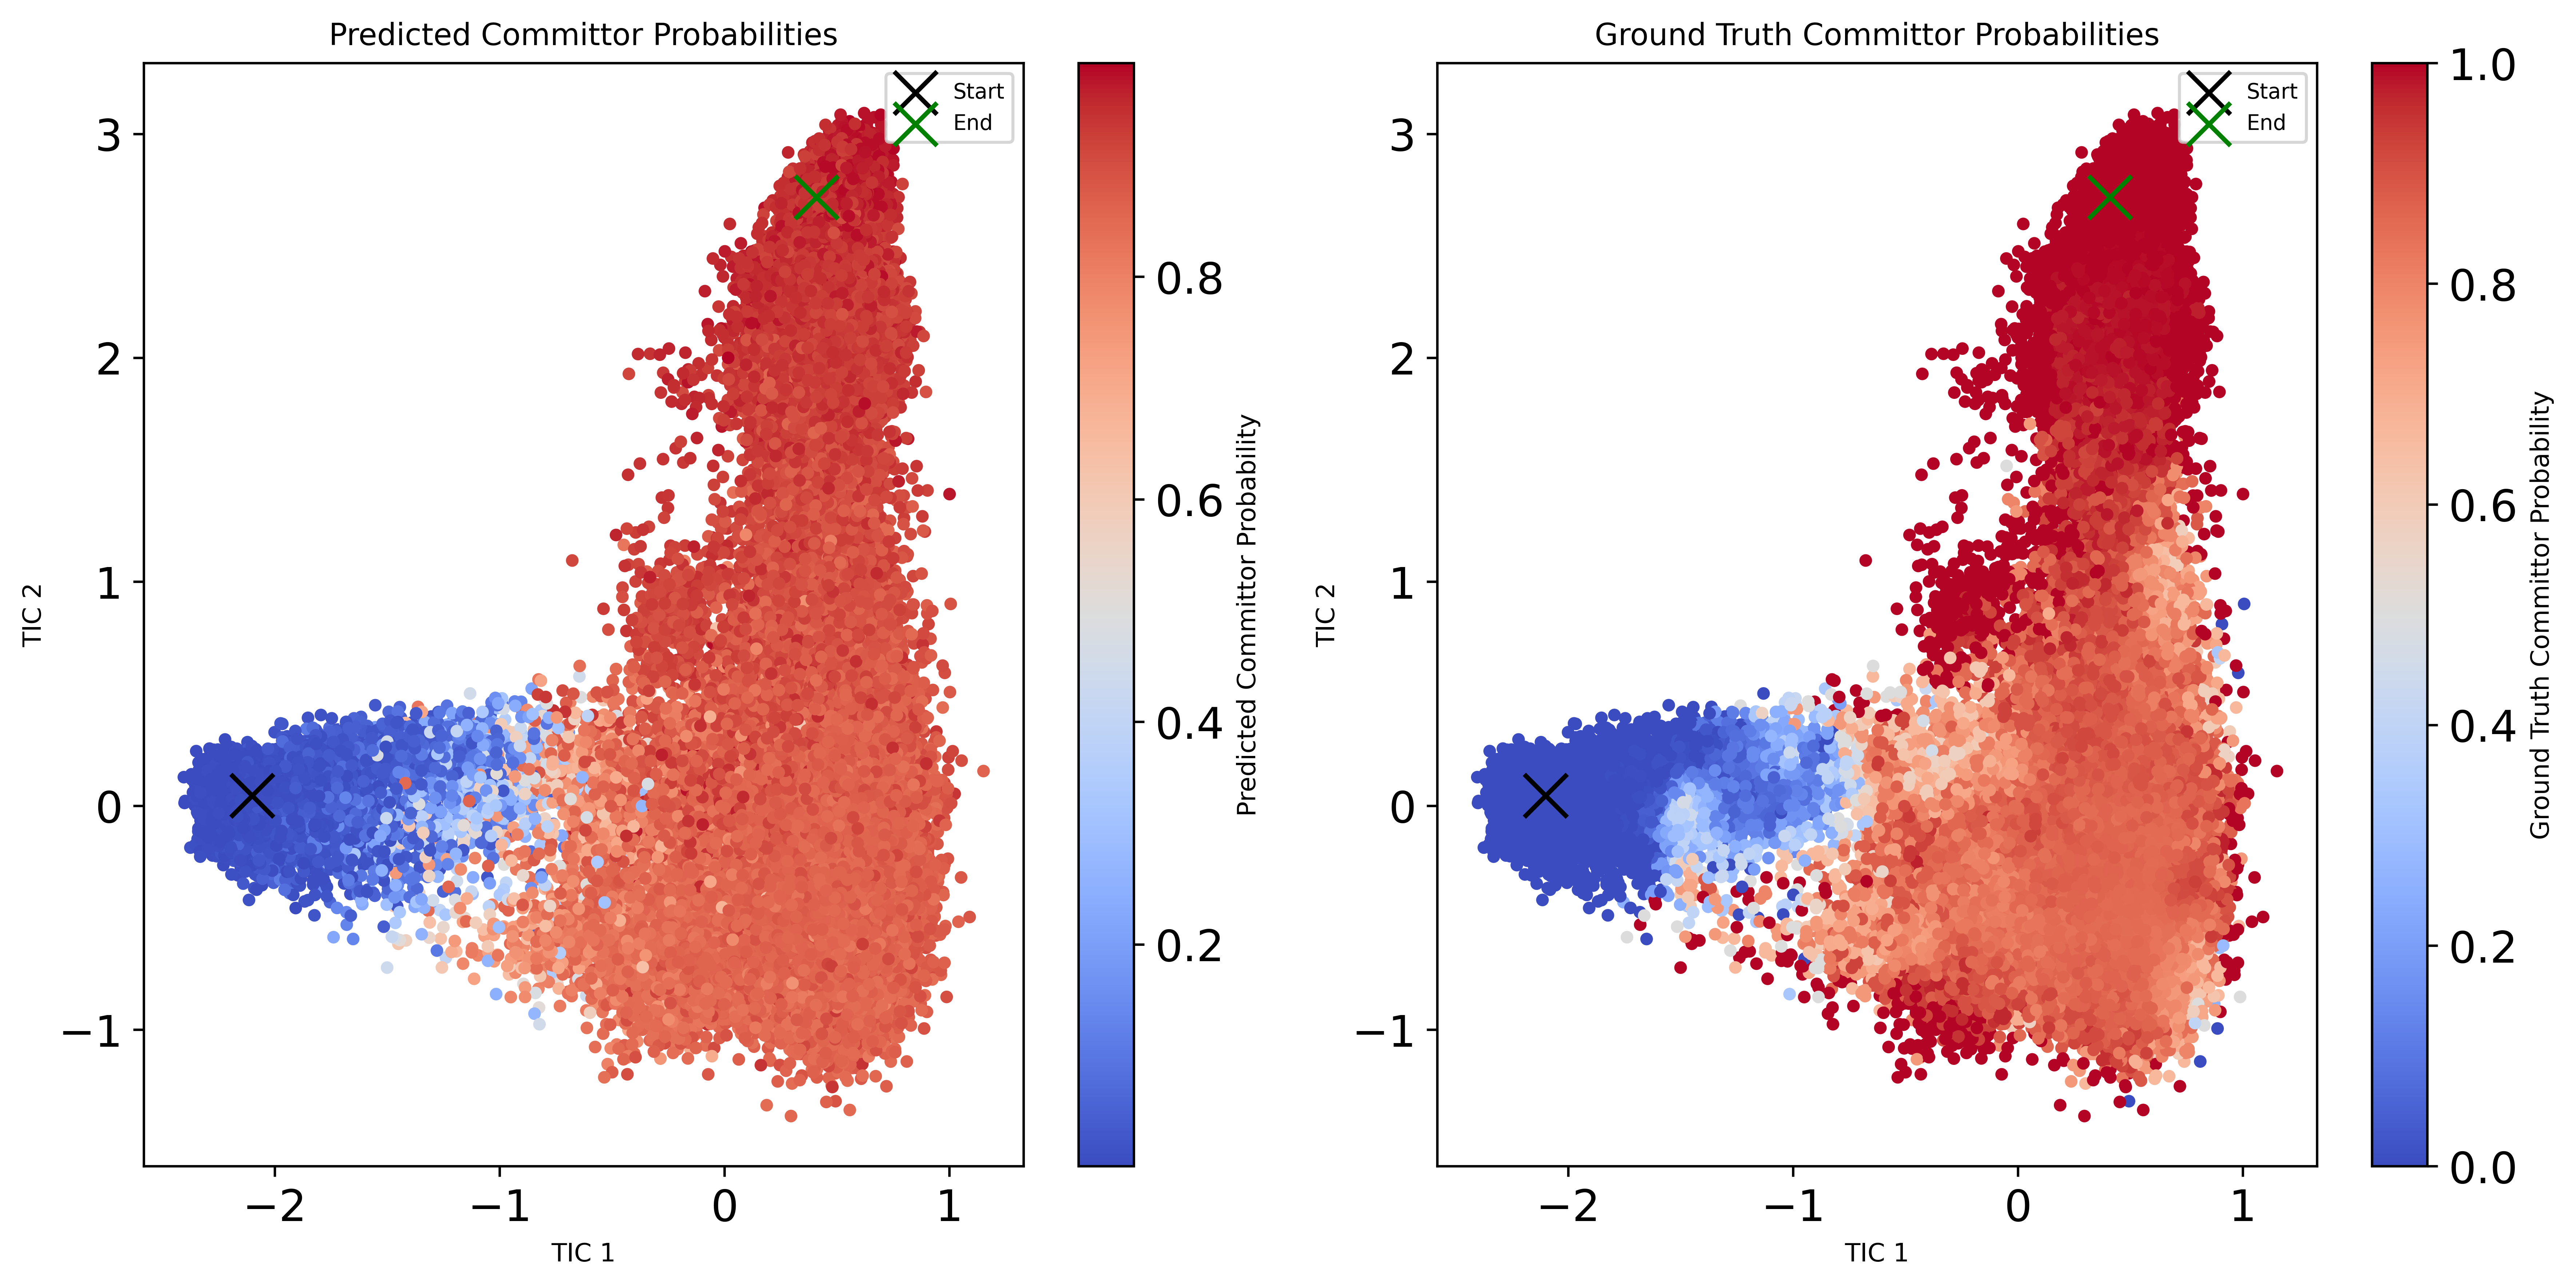

In [21]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from models import CommittorNN

# Evaluate the committor model and get predicted probabilities
model = GraphTransformer(num_beads=n_atoms, hidden_nf=64, conservative=True)
committor_model = CommittorNN(model)

committor_state_dict_file = os.path.join(
    "/home/sanjeevr/om-diffusion/two-for-one-diffusion/saved_models",
    protein_name,
    f"committor-model-{start}_{end}.pt",
)
state_dict = torch.load(committor_state_dict_file)

committor_model.load_state_dict(state_dict.state_dict())
committor_model.to(device)
committor_model.eval()

committor_probs = []
for x in tqdm(x_test.split(batch_size)):
    x = x.to(device).requires_grad_(True)
    x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
    h = torch.eye(n_atoms).to(device)
    t = torch.zeros((x.shape[0], )).to(device)
    pred_prob = committor_model(x, h, t)
    committor_probs.append(pred_prob.detach())

committor_probs = torch.cat(committor_probs).cpu().detach().numpy()

# Get TICA for the ground truth data
sample_tic_features = tic_evaluator.get_tic_features(
        x_test, tic_evaluator.folded
    )
transformed_samples = tic_evaluator.tica(sample_tic_features)

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the predicted committor probabilities
scatter1 = axs[0].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=committor_probs, cmap='coolwarm', s=10)
axs[0].set_title('Predicted Committor Probabilities')
axs[0].set_xlabel('TIC 1')
axs[0].set_ylabel('TIC 2')
axs[0].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[0].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[0].legend()
plt.colorbar(scatter1, ax=axs[0], label='Predicted Committor Probability')

# Plot the ground truth committor probabilities
scatter2 = axs[1].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=probs_test, cmap='coolwarm', s=10)
axs[1].set_title('Ground Truth Committor Probabilities')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')
axs[1].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[1].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[1].legend()
plt.colorbar(scatter2, ax=axs[1], label='Ground Truth Committor Probability')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [7]:
from ase import units
KB = 0.83144626181  # This is the Boltzmann constant conversed from J/K (Kg, m^2 / s^2 / K) to -> g/mol, angstroms, ps and K.
temp_data = 300  # Temperature in K
masses = 12.0  # Mass of carbon in g/mol
friction = 1.0  # Friction coefficient in ps^-1
def compute_rates(samples, weights, committor_model):
    """
    samples: torch.tensor of shape [N_samples, 2]
    weights: torch.tensor of shape [N_samples, 1]
    committor_model: NN trained to predict committor probabilities
    """
    weights = weights / weights.sum()
    # Loop over samples and compute grad of model-predicted committors
    committor_model.eval()
    committor_probs = []
    grad_committor_prob_norms = []
    for x in tqdm(samples.split(4096)):
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        x = x.to(torch.float32)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size]
            inputs=x,  # [batch_size, N_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=False,  # Make sure the graph is not destroyed during training
            create_graph=False,  # Create graph for second derivative
            allow_unused=True,
            )[0].detach()
        grad_committor_prob_norms.append(torch.norm(grad_prob, dim=(-2, -1))**2)
    
    grad_committor_prob_norms = torch.cat(grad_committor_prob_norms)
    
    # Compute a weighted average of the grad of the committor (this is the rate)
    ensemble_average = (weights * grad_committor_prob_norms).sum()
    rate_ps = KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) * ensemble_average
    rate_ns = rate_ps * 1e3
    N_eff = (-weights * torch.log(weights)).sum().exp()  # effective sample size

    print(f"Rate (ns^-1): {rate_ns.item()}, Effective sample size: {N_eff} out of {len(samples)} samples")
    return rate_ns, N_eff

rate, N_eff = compute_rates(torch.tensor(gt_traj_keep), torch.tensor(reweighting_factors_keep).to(device), committor_model)


NameError: name 'gt_traj_keep' is not defined

In [12]:
KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) * 1e3

804.7962075205627